In [ ]:
#%pip install merlinquantum torch numpy matplotlib

In [ ]:
import math
import importlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# MerLin package import name is usually `merlin`.
try:
    import merlin as ML
except Exception as exc:
    raise ImportError(
        "Could not import MerLin. Install with: pip install merlinquantum"
    ) from exc

print("torch", torch.__version__)
print("merlin", getattr(ML, "__version__", "version unknown"))

torch 2.10.0+cpu
merlin 0.2.3


In [ ]:
# Reproducibility and dtype
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

# MerLin's high-level layers commonly return float32 tensors.
# Keep the whole notebook in float32 to avoid errors such as:
# RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Double
torch.set_default_dtype(torch.float32)
dtype = torch.float32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("dtype:", dtype)


device: cpu
dtype: torch.float32


In [ ]:
# PDE constants
alpha = 0.1
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

def exact_u(x, t):
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)

def sample_interior(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad_(True)
    return xt

def sample_initial(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    return xt

def sample_boundary(n):
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    half = n // 2
    x0 = torch.zeros(half, 1, device=device, dtype=torch.get_default_dtype())
    x1 = torch.ones(n - half, 1, device=device, dtype=torch.get_default_dtype())
    x = torch.cat([x0, x1], dim=0)
    xt = torch.cat([x, t], dim=1)
    return xt

In [ ]:
class MerlinHeatQPINN(nn.Module):
    def __init__(self, feature_size=4, quantum_output_size=4, hidden=16):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )

        # High-level MerLin photonic layer.
        # If your installed MerLin exposes extra architecture arguments, you can add them here.
        self.quantum = ML.QuantumLayer.simple(
            input_size=feature_size,
            output_size=quantum_output_size,
        )

        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt):
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)

        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]

        # Enforce homogeneous Dirichlet boundary conditions exactly.
        u = x * (1.0 - x) * q_u
        return u, ux_hat

model = MerlinHeatQPINN().to(device=device, dtype=dtype)

# Defensive dtype alignment: if MerLin creates/returns float32 internally,
# the surrounding PyTorch layers must also be float32.
for p in model.parameters():
    if p.is_floating_point():
        p.data = p.data.to(dtype)

print(model)
print("first parameter dtype:", next(model.parameters()).dtype)

MerlinHeatQPINN(
  (feature_map): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
  (quantum): SimpleSequential(
    (quantum_layer): QuantumLayer(
      (_photon_loss_transform): PhotonLossTransform()
      (_detector_transform): DetectorTransform()
      (measurement_mapping): Probabilities()
    )
    (post_processing): ModGrouping()
  )
  (readout): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)
first parameter dtype: torch.float32


In [ ]:
import torch
import torch.nn as nn
import perceval as pcvl
import merlin as ML


def build_two_mode_circuit():
    x0 = pcvl.P("input0")
    x1 = pcvl.P("input1")

    gamma1 = pcvl.P("gamma1")
    phi1   = pcvl.P("phi1")
    theta1 = pcvl.P("theta1")

    gamma2 = pcvl.P("gamma2")
    phi2   = pcvl.P("phi2")
    theta2 = pcvl.P("theta2")

    alpha = pcvl.P("alpha")

    circ = pcvl.Circuit(2, name="custom_qpinn")

    # First beam splitter, fed by feature-map outputs as parameter shifts
    circ.add((0, 1), pcvl.BS.Rx(theta=gamma1 + x0, phi_tr=phi1 + x1))

    # R(theta1) on mode 0
    circ.add(0, pcvl.PS(theta1))

    # Second beam splitter
    circ.add((0, 1), pcvl.BS.Rx(theta=gamma2, phi_tr=phi2))

    # R(theta2) on mode 0
    circ.add(0, pcvl.PS(theta2))

    # Same phase alpha on both modes
    circ.add(0, pcvl.PS(alpha))
    circ.add(1, pcvl.PS(alpha))

    return circ

In [ ]:
class MerlinHeatQPINNCustom(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()

        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
            nn.Tanh(),
        )

        circ = build_two_mode_circuit()
        self.circuit_to_draw = circ

        self.quantum = ML.QuantumLayer(
            input_size=2,
            circuit=circ,
            input_parameters=["input"],
            trainable_parameters=["gamma", "phi", "theta", "alpha"],
            input_state=[1, 0],
            measurement_strategy=ML.MeasurementStrategy.probs(),
        )


        self.readout = nn.Sequential(
            nn.Linear(self.quantum.output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt):
        x = xt[:, 0:1]

        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)

        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]

        u = x * (1.0 - x) * q_u
        return u, ux_hat

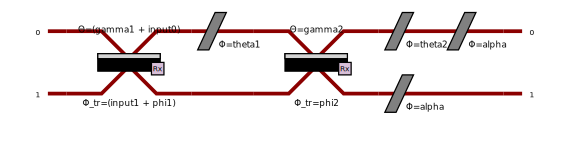

In [ ]:
model = MerlinHeatQPINNCustom()

pcvl.pdisplay(model.circuit_to_draw, recursive=False)